In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

# Load dataset (2 inputs, 1 output class)
data = pd.read_excel("three_class_dataset_integers.xlsx")
X = data[['X1', 'X2']].values
Y = data['Class'].values.reshape(-1, 1)

# One-hot encode output for 3 classes
num_classes = len(np.unique(Y))
Y_onehot = np.zeros((Y.size, num_classes))
Y_onehot[np.arange(Y.size), Y.flatten()] = 1

FileNotFoundError: [Errno 2] No such file or directory: 'three_class_dataset_integers.xlsx'

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)


file_path = "/kaggle/input/three-class/three_class_dataset_integers.xlsx"
data = pd.read_excel(file_path)

# Show info
print("Dataset shape:", data.shape)
print(data.head())


X = data[['X1', 'X2']].values
Y = data['Class'].values.reshape(-1, 1)

# One-hot encode output for 3 classes
num_classes = len(np.unique(Y))
Y_onehot = np.zeros((Y.size, num_classes))
Y_onehot[np.arange(Y.size), Y.flatten()] = 1

Dataset shape: (500, 3)
   X1  X2  Class
0   0   0      0
1   0   1      0
2   0   1      0
3   1   2      0
4   1   2      0


In [17]:
class NeuralNetwork(object):
    def __init__(self):
        inputLayerNeurons = 2
        hidden1Neurons = 10
        hidden2Neurons = 10
        outLayerNeurons = 3
        
        self.learning_rate = 0.2
        
        # Initialize weights for 3 layers
        self.W_H1I = np.random.randn(inputLayerNeurons, hidden1Neurons)
        self.W_H2H1 = np.random.randn(hidden1Neurons, hidden2Neurons)
        self.W_OH2 = np.random.randn(hidden2Neurons, outLayerNeurons)
        
    def sigmoid(self, x, der=False):
        if der:
            return x * (1 - x)
        else:
            return 1 / (1 + np.exp(-x))
        
    def feedForward(self, X):
        # Input → Hidden Layer 1
        hidden1_input = np.dot(X, self.W_H1I)
        self.hidden1_output = self.sigmoid(hidden1_input)
        
        # Hidden Layer 1 → Hidden Layer 2
        hidden2_input = np.dot(self.hidden1_output, self.W_H2H1)
        self.hidden2_output = self.sigmoid(hidden2_input)
        
        # Hidden Layer 2 → Output
        output_input = np.dot(self.hidden2_output, self.W_OH2)
        pred = self.sigmoid(output_input)
        return pred
        
    def backPropagation(self, X, Y, pred):
        # Output layer
        output_error = Y - pred
        output_delta = self.learning_rate * output_error * self.sigmoid(pred, der=True)
        
        # Hidden layer 2
        hidden2_error = output_delta.dot(self.W_OH2.T)
        hidden2_delta = self.learning_rate * hidden2_error * self.sigmoid(self.hidden2_output, der=True)
        
        # Hidden layer 1
        hidden1_error = hidden2_delta.dot(self.W_H2H1.T)
        hidden1_delta = self.learning_rate * hidden1_error * self.sigmoid(self.hidden1_output, der=True)
        
        # Update weights
        self.W_OH2 += self.hidden2_output.T.dot(output_delta)
        self.W_H2H1 += self.hidden1_output.T.dot(hidden2_delta)
        self.W_H1I += X.T.dot(hidden1_delta)
        
    def train(self, X, Y):
        output = self.feedForward(X)
        self.backPropagation(X, Y, output)

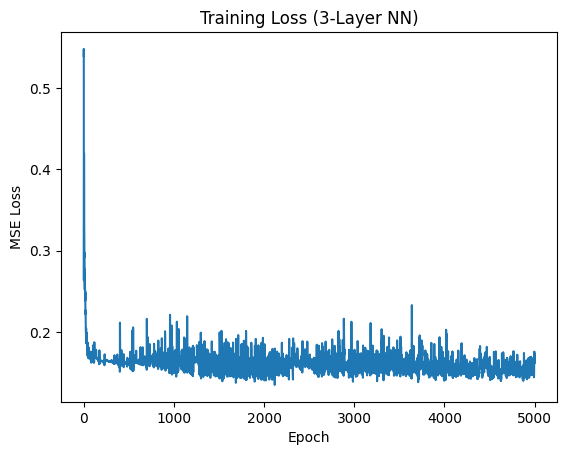

In [18]:
NN = NeuralNetwork()
err = []

for i in range(5000):
    NN.train(X, Y_onehot)
    err.append(np.mean(np.square(Y_onehot - NN.feedForward(X))))


plt.plot(err)
plt.title("Training Loss (3-Layer NN)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [19]:
print(NN.feedForward([13,7]))

[0.52640314 0.38234631 0.08847478]


In [20]:
print(NN.feedForward([-17,9]))

[1.53546193e-04 9.90347875e-01 4.38618860e-02]


In [34]:
print(NN.feedForward([12,-18]))

[0.5206011  0.00091598 0.38848217]
